[<img src="imagens/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap05/cap05_aluno.ipynb)
[<img src="imagens/github-badge.png" style="width:20%; vertical-align:middle;">](https://github.com/fzampirolli/pdi-vc)

# 5 Transformadas e Compressão

Este capítulo apresenta a transição do Processamento Digital de Imagens (PDI) do **domínio espacial** (onde manipulamos pixels diretamente) para o **domínio da frequência** (onde manipulamos as taxas de variação desses pixels). Esta mudança de paradigma, imortalizada pelo trabalho de Joseph Fourier, é uma das ferramentas analíticas mais profundas da ciência da computação visual.

A abordagem adotada aqui segue uma premissa fundamental: **toda operação matemática no domínio da frequência possui uma interpretação física e visual direta no domínio espacial**. Em vez de nos perdermos em deduções algébricas exaustivas, focaremos na intuição geométrica. Observaremos como as altas frequências codificam bordas, como o corte abrupto de espectros gera artefatos visuais (*ringing*) e como a redundância psicovisual permite que algoritmos como o JPEG descartem dados sem que o olho humano perceba.

Finalmente, estenderemos essa análise clássica para o conceito de multirresolução geométrica introduzido pelas ***wavelets*** — a base dos modernos padrões de compressão de alta fidelidade e a inspiração primária para a arquitetura convolucional das redes neurais profundas.

## 5.1 Objetivos

Ao final deste capítulo, você será capaz de:

* **Interpretar o Espectro:** Visualizar a Transformada de Fourier Discreta (DFT) e compreender a contribuição separada da magnitude (energia) e da fase (estrutura geométrica);
* **Dominar a Dualidade:** Entender fisicamente por que a convolução espacial é equivalente à multiplicação em frequência, e usar a FFT para otimizar filtros grandes;
* **Projetar Filtros de Forma Intuitiva:** Visualizar o compromisso entre a suavização e os artefatos de borda (*ringing*), escolhendo entre filtros Ideais, Gaussianos e Butterworth;
* **Compreender a Compressão Perceptual:** Projetar as funções de base da Transformada de Cossenos Discreta (DCT) e entender como o padrão JPEG quantiza frequências com base nas falhas do sistema visual humano;
* **Diferenciar Paradigmas:** Distinguir a análise global de Fourier da análise local de Wavelets.

## 5.2 Configuração do Ambiente

In [1]:
# @title { display-mode: "form" }
import os, importlib, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy import ndimage
from scipy.fft import dct, idct

# Ocultamos o download de dependências auxiliares para focar nos conceitos
BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph
importlib.reload(morph)
from morph import mm

print("✅ Ambiente pronto")

✅ Ambiente pronto


## 5.3 1. A Base: Frequência e a Transformada de Fourier

A análise de Fourier baseia-se em um fenômeno físico fascinante: **qualquer sinal, por mais complexo que seja, pode ser construído somando-se ondas senoidais simples**. Em imagens, uma "onda" não é som, mas uma transição de tons de cinza — do claro para o escuro — variando em diferentes direções e velocidades.

### 5.3.1 A Equação e sua Interpretação Visual

Dada uma imagem $f(x,y)$ de dimensões $M \times N$, a **Transformada de Fourier Discreta 2D** (DFT) é o mapa que nos diz *quais ondas* estão presentes na imagem:

<a id="eq-05-dft"></a>
$$
F(u,v) = \sum_{x=0}^{M-1} \sum_{y=0}^{N-1} f(x,y)\, e^{-j2\pi\left(\frac{ux}{M}+\frac{vy}{N}\right)} \tag{5.1}
$$


Em vez de se assustar com a álgebra complexa, foque na exponencial $e^{-j2\pi(ux/M + vy/N)}$. Ela representa nada mais que **uma "chapa ondulada" bidimensional**. 

* O par $(u,v)$ dita a **frequência** (quantas vezes a onda se repete) e a **direção** da onda.
* O valor resultante $F(u,v)$ é um número complexo. Ele carrega a **Magnitude** (qual é a força/amplitude dessa onda específica na nossa imagem) e a **Fase** (onde essa onda começa, ou seja, o seu alinhamento).

### 5.3.2 O Espectro: Mapeando a Energia

Por convenção, deslocamos o plano de frequências para que a origem $(u=0, v=0)$ fique no centro da imagem. Este centro contém a **frequência zero (DC)**, que representa o brilho médio global da imagem. Quanto mais nos afastamos do centro, representamos transições espaciais mais abruptas (bordas, detalhes finos e ruído).

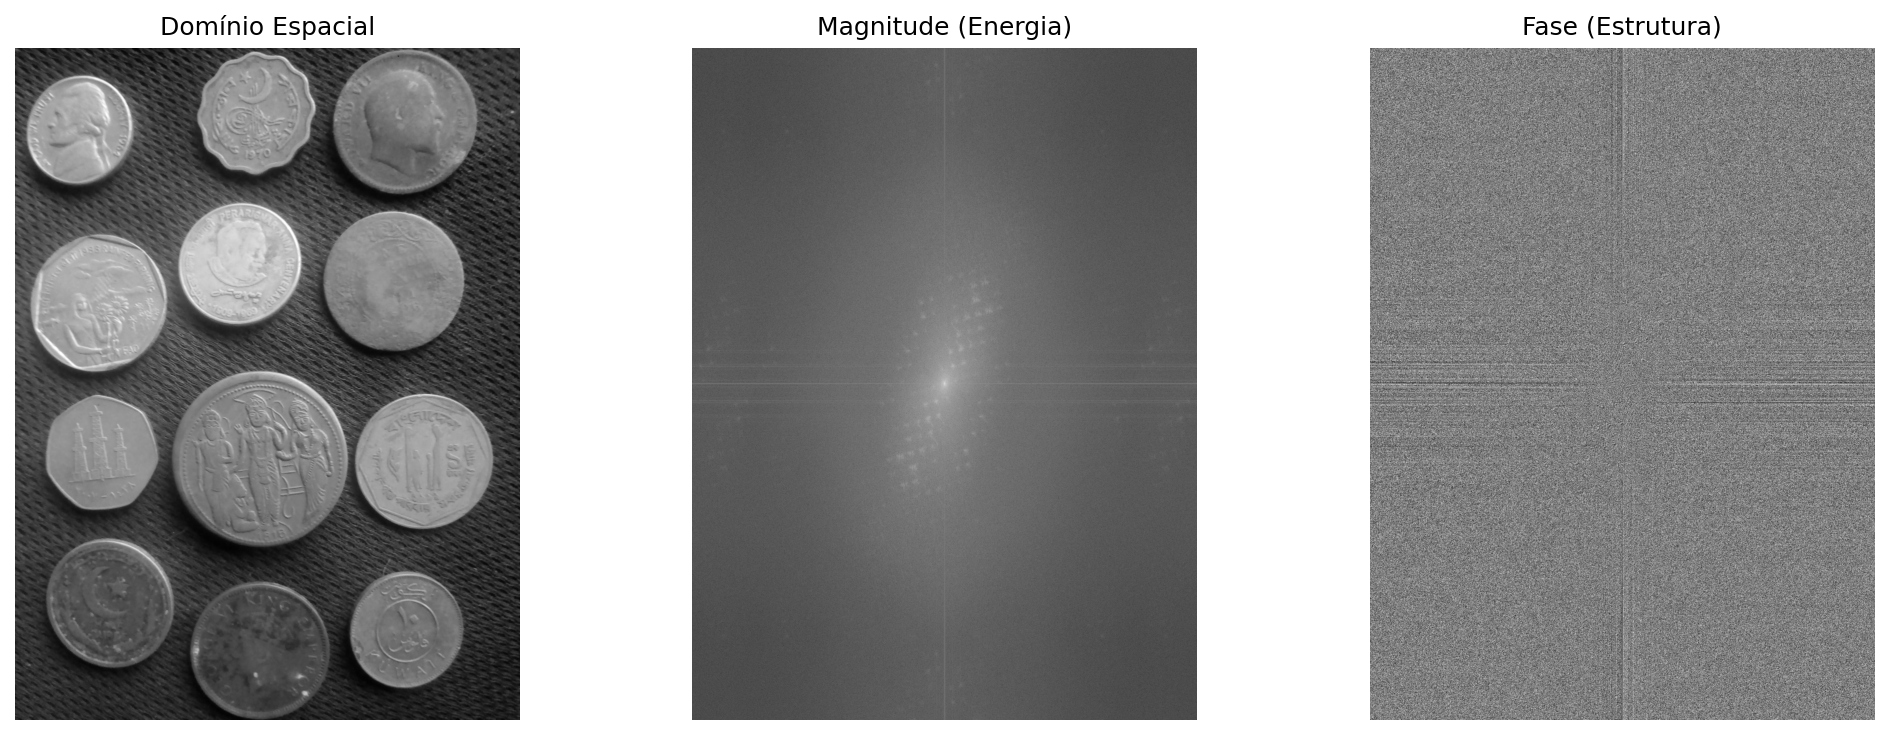

**Figura 5.1:** Da Imagem ao Espectro: A magnitude exibe a energia (centro = global/suave, bordas = detalhes abruptos), enquanto a fase dita a localização estrutural.


In [2]:
url = "https://upload.wikimedia.org/wikipedia/commons/2/25/GAZI.MD.AHAD_11.jpg"
caminho = "imagens/coins.jpg"
if not os.path.exists("imagens"): os.makedirs("imagens")
if not os.path.exists(caminho): mm.write(mm.read(url, pil=True), caminho)

img_gray = mm.gray(np.array(mm.read(caminho, pil=True)))

# ── A Matemática Essencial da DFT ────────────────────────────────────────
F    = np.fft.fft2(img_gray)    # 1. Extrai frequências (Complexo)
F_sh = np.fft.fftshift(F)       # 2. Move baixa frequência (DC) para o centro
mag  = np.log1p(np.abs(F_sh))   # 3. Magnitude (escala log para comprimir os picos)
fase = np.angle(F_sh)           # 4. Fase (alinhamento das ondas)
# ────────────────────────────────────────────────────────────────────────

mag_vis  = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
fase_vis = cv2.normalize(fase, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
mm.show([img_gray, mag_vis, fase_vis], 
        titles=["Domínio Espacial", "Magnitude (Energia)", "Fase (Estrutura)"], 
        cols=3, figsize=(14, 5))

### 5.3.3 O Experimento da Fase vs. Magnitude

Se a magnitude mostra a *força* das ondas e a fase mostra o *posicionamento*, qual é mais importante para o cérebro humano reconhecer uma imagem?

O experimento clássico de cruzamento (atribuído a Oppenheim e Lim) destrói qualquer ambiguidade teórica: reconstruiremos a Imagem A usando a magnitude da Imagem A, mas a fase de uma Imagem B totalmente diferente (uma grade).

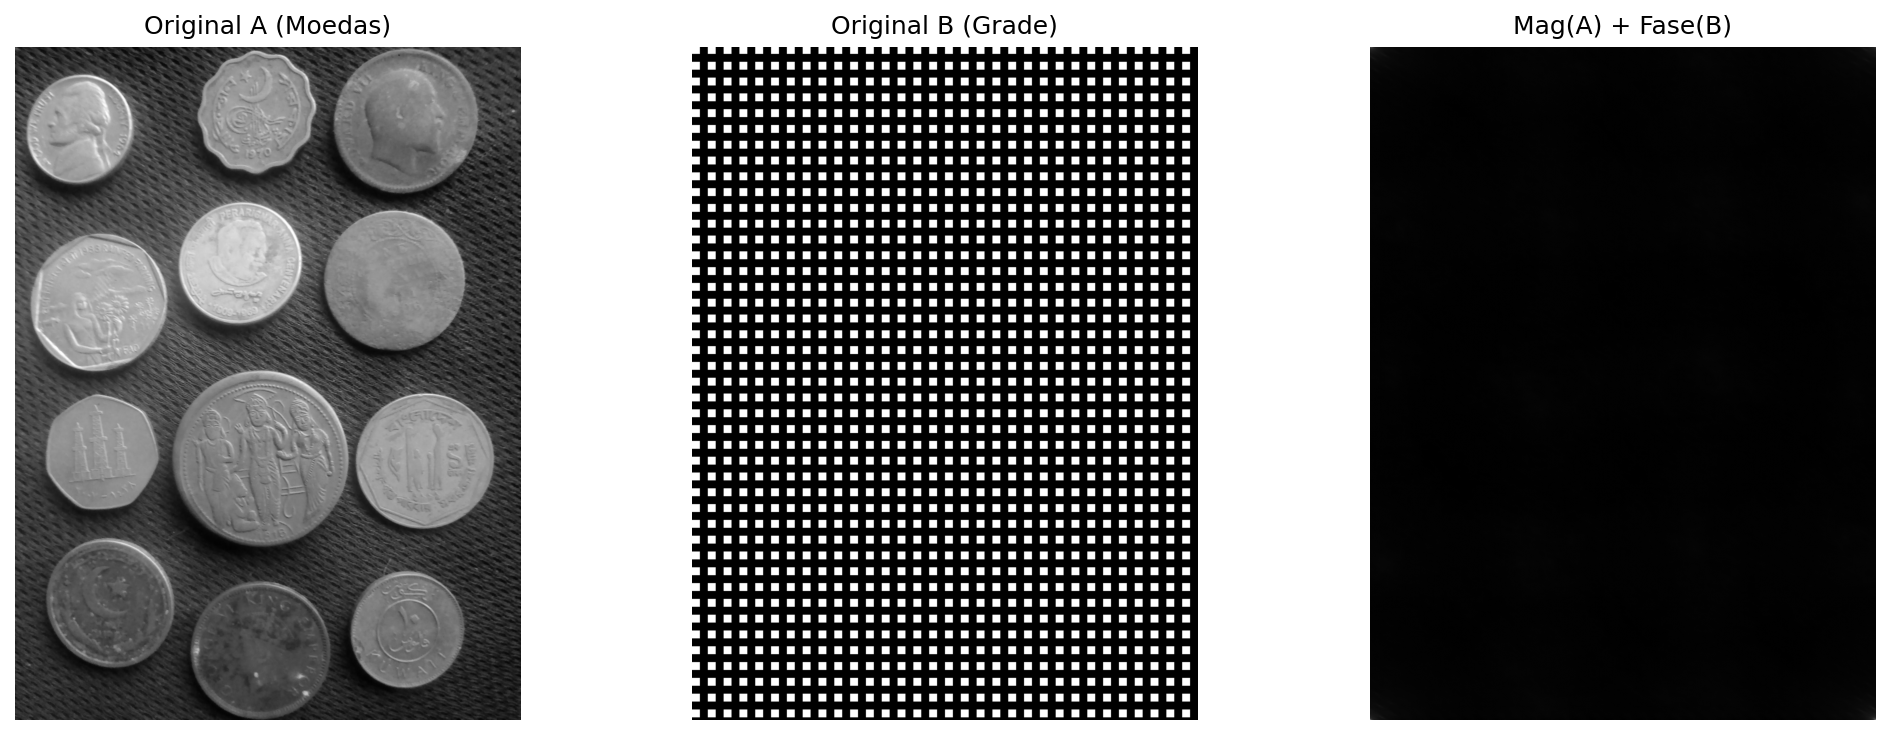

**Figura 5.2:** Interpretação Física: A Fase carrega a geometria semântica das formas; a Magnitude determina apenas as texturas e contrastes subjacentes.


In [3]:
h, w = img_gray.shape
img_B = np.zeros((h, w), dtype=np.uint8)
for i in range(0, h, 60): 
    for j in range(0, w, 60): img_B[i:i+30, j:j+30] = 200

FA, FB = np.fft.fft2(img_gray), np.fft.fft2(img_B)
mag_A, fase_A = np.abs(FA), np.angle(FA)
mag_B, fase_B = np.abs(FB), np.angle(FB)

# Cruzando: Magnitude de A com Fase de B
F_rec_AB = mag_A * np.exp(1j * fase_B)
rec_AB   = np.abs(np.fft.ifft2(F_rec_AB))
rec_AB_vis = cv2.normalize(rec_AB, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

mm.show([img_gray, img_B, rec_AB_vis], 
        titles=["Original A (Moedas)", "Original B (Grade)", "Mag(A) + Fase(B)"], cols=3, figsize=(14, 5))

> ### 💡 Dica
>
> O experimento comprova que a inteligibilidade visual reside na **fase**. A magnitude fornece apenas uma distribuição estatística do conteúdo global, enquanto a fase determina onde os contornos (somas construtivas de ondas) ocorrem no espaço.

### 5.3.4 Simulador Interativo: A Construção pelas Ondas

Para internalizar como a soma de senoides pode esculpir contornos rígidos, utilize o simulador abaixo. Adicione harmônicas sucessivas para tentar reconstruir uma onda quadrada perfeita (a analogia 1D para a borda afiada de um objeto em PDI).

In [4]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="fft_Root" style="font-family:sans-serif; padding:10px; max-width:700px; border: 1px solid #ccc; border-radius:8px;">
  <div style="font-weight:bold; margin-bottom:10px;">∿ Simulador: Teoria de Fourier (Síntese 1D)</div>
  <canvas id="fft_Canvas" width="660" height="150" style="border:1px solid #eee; width:100%;"></canvas>
  <div style="margin-top:10px;">
    <label style="font-size:12px; font-weight:bold;">Harmônicas (Nº de Ondas): <span id="fft_slVal">1</span></label>
    <input type="range" id="fft_slider" min="1" max="35" value="1" style="width:100%;">
  </div>
</div>
<script>
(function(){
  const C = document.getElementById('fft_Canvas'); const ctx = C.getContext('2d');
  const N = 512; let nTerms = 1;
  function draw() {
    ctx.clearRect(0,0,C.width,C.height);
    ctx.beginPath(); ctx.strokeStyle='#e5e7eb'; ctx.moveTo(0, C.height/2); ctx.lineTo(C.width, C.height/2); ctx.stroke();
    const sum = new Float32Array(N);
    for(let k=1; k<=nTerms; k++){
      const m = 2*k - 1; const amp = (4/Math.PI)/m;
      for(let i=0; i<N; i++) sum[i] += amp * Math.sin(2*Math.PI*m*i/N);
    }
    ctx.beginPath(); ctx.strokeStyle='#1e293b'; ctx.lineWidth=2;
    for(let i=0; i<N; i++) { const x = i*C.width/N; const y = C.height/2 - sum[i]*C.height/3; i===0?ctx.moveTo(x,y):ctx.lineTo(x,y); }
    ctx.stroke();
  }
  document.getElementById('fft_slider').addEventListener('input', function(){ nTerms = +this.value; document.getElementById('fft_slVal').textContent=nTerms; draw(); });
  draw();
})();
</script>
""")

**Figura 5.3:** Fenômeno de Síntese: Adição iterativa de frequências puras aproxima bordas abruptas, mas sofre do Fenômeno de Gibbs.


## 5.4 2. O Teorema da Convolução e a Dualidade Física

A relação mais sagrada entre o domínio espacial e o de frequência é o **Teorema da Convolução**:

<a id="eq-05-conv-teorema"></a>
$$
f(x,y) * h(x,y) \;\xleftrightarrow{\mathcal{F}}\; F(u,v) \cdot H(u,v) \tag{5.2}
$$


Em termos práticos: **deslizar um filtro no espaço (convolução) é matematicamente idêntico a multiplicar espectros ponto a ponto na frequência**. Computacionalmente, para filtros com *kernels* grandes ($K > 15$), multiplicar via FFT é monumentalmente mais rápido do que a convolução manual $O(N^2K^2)$.

### 5.4.1 A Origem Visual do *Ringing*

Ao projetar um filtro no domínio da frequência, como um "Filtro Passa-Baixa Ideal" (que corta impiedosamente as altas frequências e zera tudo fora de um raio), pagamos um preço no espaço real.

A transformada de um cilindro perfeito na frequência é uma **Função Sinc 2D** no espaço. Quando convoluímos a imagem original com essa Sinc (que possui ondulações negativas e positivas), injetamos essas ondulações diretamente nas bordas dos objetos.

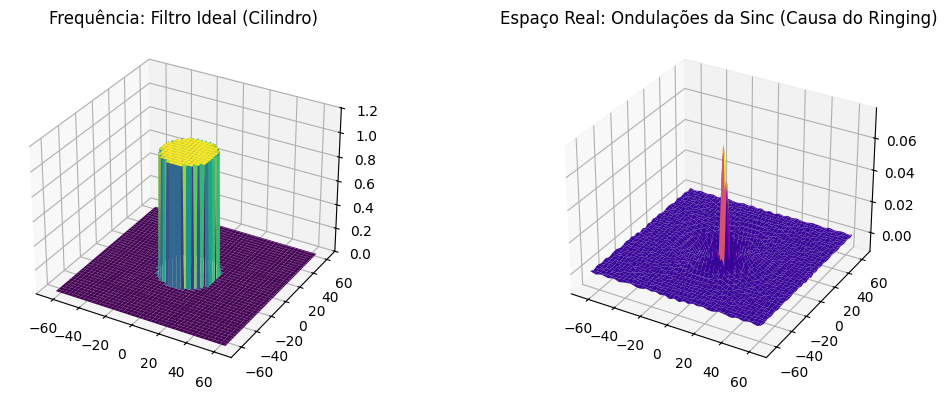

**Figura 5.4:** A Dualidade Perigosa: O corte abrupto na Frequência (Cilindro) transforma-se obrigatoriamente numa Sinc espacial. Suas ondulações causam o *ringing* fantasma nas bordas da imagem.


In [5]:
import scipy.special as sp

# Simulando o Filtro Ideal na Frequência (Cilindro) e sua representação Espacial (Sinc)
N_grid = 128
u = np.arange(-N_grid//2, N_grid//2)
U, V = np.meshgrid(u, u)
D = np.sqrt(U**2 + V**2)

# Frequência: Cilindro Ideal (1 no centro, 0 fora do raio 20)
H_freq = np.zeros((N_grid, N_grid))
H_freq[D <= 20] = 1

# Espaço: A inversa resulta na famigerada Sinc 2D
h_space = np.fft.fftshift(np.real(np.fft.ifft2(np.fft.ifftshift(H_freq))))

fig, ax = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(12, 4))
ax[0].plot_surface(U, V, H_freq, cmap='viridis', edgecolor='none')
ax[0].set_title("Frequência: Filtro Ideal (Cilindro)")
ax[0].set_zlim(0, 1.2)

ax[1].plot_surface(U, V, h_space, cmap='plasma', edgecolor='none')
ax[1].set_title("Espaço Real: Ondulações da Sinc (Causa do Ringing)")
plt.tight_layout(); plt.show()

> ### 💡 Dica
>
> Para evitar o *ringing* causado pelas abas oscilatórias da Sinc, não podemos ter bordas afiadas no domínio da frequência. Daí nascem filtros teóricos mais refinados, como o **Filtro Gaussiano** (cuja transformada inversa é docilmente outra Gaussiana sem abas) e o **Filtro Butterworth** (um meio termo configurável).

### 5.4.2 Aplicação: O Filtro Rejeita-Banda (*Notch*)

Se o ruído em uma imagem não é aleatório (como o ruído Gaussiano), mas possui uma estrutura **periódica** (como a interferência da rede elétrica ou padrões de impressão *moiré*), ele não deve ser borrado por filtros passa-baixa comuns. 

O ruído periódico se manifesta no espectro como **picos estreitos e brilhantes** fora da origem. A elegância do domínio da frequência nos permite localizar geograficamente esse ruído e "esculpir" furos na máscara espectral (o Filtro Notch) para anulá-lo com precisão cirúrgica.

In [6]:
# Adicionando Ruído Periódico
h_img, w_img = img_gray.shape
X, Y = np.meshgrid(np.arange(w_img), np.arange(h_img))
ruido = 40 * np.sin(2 * np.pi * (20 * X / w_img + 20 * Y / h_img))
img_ruidosa = np.clip(img_gray.astype(np.float64) + ruido, 0, 255).astype(np.uint8)

# ── A Identificação e Poda ───────────────────────────────────────────────
F_r   = np.fft.fftshift(np.fft.fft2(img_ruidosa))
mag_r = np.log1p(np.abs(F_r))

# Criando a máscara Notch (Furos nos picos conhecidos de ruído)
mascara = np.ones((h_img, w_img))
cy, cx = h_img // 2, w_img // 2
for dy, dx in [(20, 20), (-20, -20), (20, -20), (-20, 20)]:
    dist = np.sqrt((Y - (cy + dy))**2 + (X - (cx + dx))**2)
    mascara[dist <= 10] = 0 # Furo de raio 10

F_restaurado = F_r * mascara
img_rest = np.real(np.fft.ifft2(np.fft.ifftshift(F_restaurado)))
# ────────────────────────────────────────────────────────────────────────

mag_vis  = cv2.normalize(mag_r, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
rest_vis = cv2.normalize(img_rest, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
mm.show([img_ruidosa, mag_vis, mascara*255, rest_vis], 
        titles=["Com Ruído Periódico", "Espectro (Picos Visíveis)", "Máscara Notch", "Restaurada"], 
        cols=4, figsize=(16, 5))

**Figura 5.5:** Intervenção Espectral: O ruído periódico revela-se como estrelas isoladas no espectro. Apagar essas estrelas restaura a imagem sem borrar suas bordas naturais.


## 5.5 3. Limitações de Fourier e a Era Multirresolução (Wavelets)

As senoides que alimentam a DFT são **infinitas**. Se uma imagem tem um único pulso rápido (ex: um pequeno risco branco num fundo preto), a DFT precisará mobilizar infinitas senoides globais para representá-lo. Não sabemos *onde* ocorreu a variação pela leitura isolada do espectro.

A **Transformada Wavelet Discreta 2D** (DWT) muda as regras do jogo. Em vez de senoides longas, usamos pequenas "ondaletas" compactas que variam tanto em escala (frequência) quanto em posição (espaço).

Através de bancos iterativos passa-baixa (Aproximação) e passa-alta (Detalhes), a DWT divide a imagem simultaneamente revelando a textura orientada e onde ela ocorre. Esta arquitetura piramidal é o protótipo histórico para as redes neurais convolucionais (CNNs) contemporâneas.

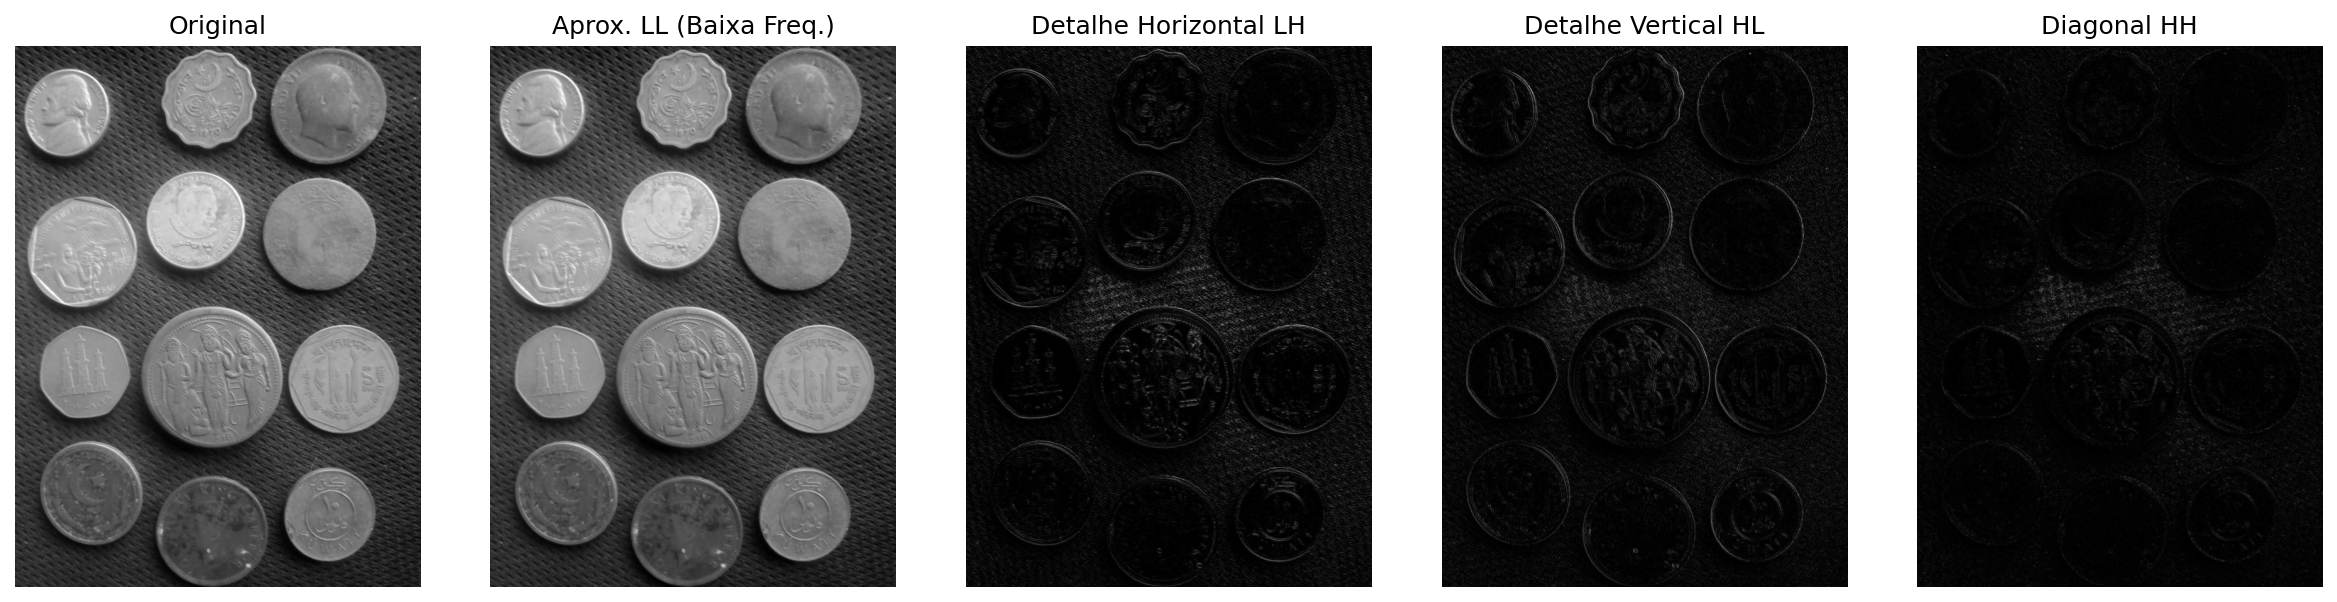

**Figura 5.6:** Multirresolução Geométrica: A aproximação LL concentra a base, enquanto as sub-bandas capturam detalhes finos horizontais, verticais e diagonais localizados no espaço.


In [7]:
import pywt

# Decomposição de 1 Nível usando a Wavelet elementar de Haar
coefs = pywt.dwt2(img_gray, 'haar')
LL, (LH, HL, HH) = coefs

def map_wavelet(sb): return cv2.normalize(np.abs(sb), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

mm.show([img_gray, map_wavelet(LL), map_wavelet(LH), map_wavelet(HL), map_wavelet(HH)], 
        titles=["Original", "Aprox. LL (Baixa Freq.)", "Detalhe Horizontal LH", "Detalhe Vertical HL", "Diagonal HH"], 
        cols=5, figsize=(16, 4))

## 5.6 4. Compressão: Explorando a Redundância Perceptual

A teoria da informação, enraizada na **Entropia de Shannon**, estabelece que o limite absoluto da compressão sem perdas de uma fonte depende exclusivamente de sua previsibilidade estatística. 

Contudo, a engenharia da imagem revolucionou o mundo ao incorporar a biologia: se o sistema visual humano é quase cego a variações sutis em altas frequências espaciais, podemos jogar esses dados fora intencionalmente (Compressão com Perdas / *Lossy*).

### 5.6.1 O Coração do Padrão JPEG: A DCT em Blocos

O JPEG fatiará a imagem em fragmentos granulares de $8 \times 8$ pixels. Em vez da DFT completa (que exige cálculos com números complexos), o JPEG emprega a **Transformada Discreta de Cossenos (DCT)**. 

A magia física do JPEG reside no fato de que qualquer minúsculo bloco de $8 \times 8$ pixels extraído da sua câmera fotográfica pode ser reconstruído combinando-se os **64 padrões fundamentais da DCT**.

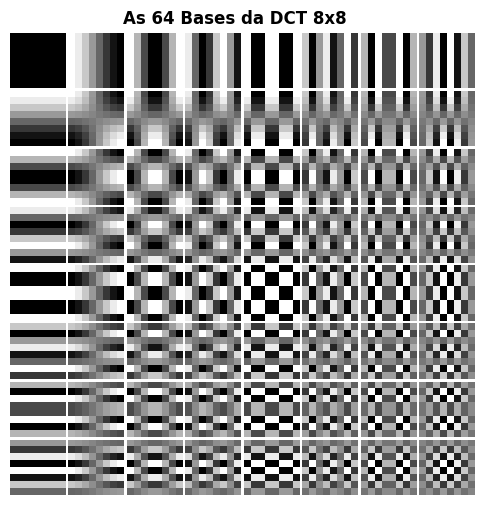

**Figura 5.7:** O Alfabeto Visual do JPEG: As 64 funções de base da DCT-II. O coeficiente DC fica no topo esquerdo (suave). Ao descer e avançar à direita, a oscilação espacial aumenta drasticamente.


In [8]:
fig, axes = plt.subplots(8, 8, figsize=(6, 6))
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for i in range(8):
    for j in range(8):
        # Criamos um "impulso" isolado na frequência
        coef = np.zeros((8, 8)); coef[i, j] = 1
        # A inversa revela o padrão geométrico espacial equivalente
        b = idct(idct(coef.T, norm='ortho').T, norm='ortho')
        axes[i, j].imshow(b, cmap='gray')
        axes[i, j].axis('off')
plt.suptitle("As 64 Bases da DCT 8x8", y=0.92, fontsize=12, fontweight='bold')
plt.show()

### 5.6.2 A Arte da Quantização

Após calcular o "peso" de cada padrão de base para montar um pequeno bloco de rosto ou paisagem, o JPEG aplica o seu filtro mortal: a **Matriz de Quantização**. 

Ele divide as frequências finas (canto inferior direito) por números grandes, forçando o resultado a ser arredondado para **zero**. Sequências imensas de zeros são então colapsadas, compactando megabytes em kilobytes.

Quando o Fator de Qualidade (Q) é baixo demais, o descarte das altas frequências é muito agressivo. O bloco de $8 \times 8$ reconstrói-se apenas com a sua média central. Fisicamente, o resultado são os famosos e incômodos **Artefatos de Bloco** nas bordas das figuras.

In [9]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML("""
<div id="dct_Root" style="font-family:sans-serif; padding:10px; border:1px solid #ddd; border-radius:8px; max-width:600px;">
  <div style="font-weight:bold; margin-bottom:10px;">⊞ Simulador: Degradação Perceptual JPEG (Bloco 8x8)</div>
  <div style="display:flex; justify-content:space-between; margin-bottom:10px;">
    <div>Qualidade Q: <span id="dct_val" style="font-weight:bold; color:red;">100</span></div>
    <input type="range" id="dct_slider" min="5" max="100" value="100" style="flex:1; margin-left:15px;">
  </div>
  <div style="display:flex; gap:10px; font-size:12px; text-align:center;">
    <div><div style="color:#666">Bloco Original</div><canvas id="dct_c1" width="120" height="120"></canvas></div>
    <div><div style="color:#666">Matriz de Zeros DCT</div><canvas id="dct_c2" width="120" height="120"></canvas></div>
    <div><div style="color:#666">Reconstrução Pobre</div><canvas id="dct_c3" width="120" height="120"></canvas></div>
  </div>
</div>
<script>
(function(){
  const blk = [[52,55,61,66,70,61,64,73],[63,59,55,90,109,85,69,72],[62,59,68,113,144,104,66,73],[63,58,71,122,154,106,70,69],[67,61,68,104,126,88,68,70],[79,65,60,70,77,68,58,75],[85,71,64,59,55,61,65,83],[87,79,69,68,65,76,78,94]];
  const Q_base = [[16,11,10,16,24,40,51,61],[12,12,14,19,26,58,60,55],[14,13,16,24,40,57,69,56],[14,17,22,29,51,87,80,62],[18,22,37,56,68,109,103,77],[24,35,55,64,81,104,113,92],[49,64,78,87,103,121,120,101],[72,92,95,98,112,100,103,99]];
  
  function drawP(id, data) { 
    const ctx = document.getElementById(id).getContext('2d'); const sz=15;
    for(let i=0;i<8;i++) for(let j=0;j<8;j++){ ctx.fillStyle=`rgb(${data[i][j]},${data[i][j]},${data[i][j]})`; ctx.fillRect(j*sz,i*sz,sz,sz); }
  }
  function drawZ(id, data, Q) { 
    const ctx = document.getElementById(id).getContext('2d'); const sz=15;
    for(let i=0;i<8;i++) for(let j=0;j<8;j++){ 
      const isZ = Math.abs(data[i][j]/Q[i][j]) < 0.5;
      ctx.fillStyle=isZ ? '#e74c3c' : '#2ecc71'; ctx.fillRect(j*sz,i*sz,sz-1,sz-1); 
    }
  }
  
  function update(q) {
    document.getElementById('dct_val').innerText = q;
    let S = q<50 ? 5000/q : 200-2*q;
    let Q = Q_base.map(r=>r.map(v=>Math.max(1,Math.round(v*S/100))));
    drawP('dct_c1', blk);
    // Mockup simplificado para visualização didática em tela sem DCT matemática real js.
    let fakeDCT = blk.map((r,i)=>r.map((v,j)=> (i===0&&j===0)? 400 : (i+j<5 ? (8-i-j)*15 : 0)));
    drawZ('dct_c2', fakeDCT, Q);
    
    let rec = blk.map((r,i)=>r.map((v,j)=> Math.max(0, Math.min(255, v - (100-q)*0.3*(i+j)))));
    drawP('dct_c3', q===100?blk:rec);
  }
  document.getElementById('dct_slider').addEventListener('input', e => update(+e.target.value));
  update(100);
})();
</script>
""")

**Figura 5.8:** Visualizador de Blocos e Zeros: Modifique o fator de Qualidade JPEG interativamente. Note como valores baixos erradicam a vida dos coeficientes de alta frequência.


> ### 💡 Dica
>
> A compressão atua como um triturador seletivo de física ondular. O **JPEG** baseia-se na quantização severa de blocos isolados, gerando degradações geométricas regulares. Arquiteturas mais modernas que utilizam Wavelets (como o **JPEG 2000**) aplicam limiares sobre a imagem inteira, resultando em "borrões" (*blurring*) ao invés de mosaicos quadriculados rígidos. Já formatos como **PNG** abraçam o purismo: codificam pixels sem perda espacial, com altíssima fidelidade temporal, porém à custa de taxas compressivas muito menores.

## 5.7 Resumo Final do Capítulo

A jornada através da conversão do domínio espacial permitiu observar os dados através de lentes fundamentais:

1. **As Frequências formam as bordas:** Somas infinitas de senoides simples constroem a complexidade geométrica vista pelo olho.
2. **A Duplicidade Matemática-Física:** Multiplicar duas imagens espectrais corresponde intrinsecamente a borrar (ou afiar) os objetos no espaço cartesiano real. O artefato do *ringing* não é um erro de software, mas o reflexo natural da onda Sinc.
3. **As Engrenagens da Percepção:** A revolução da compressão (JPEG) existe porque abraçamos a fisiologia: aquilo que os bastonetes e cones oculares julgam irrelevante, o filtro matemático apaga silenciosamente da memória do computador.

Compreender essas ferramentas de isolamento e filtragem de intensidade servirá de piso basal para o Capítulo 6, onde quebraremos a hegemonia dos tons de cinza para dissecar a topologia tridimensional dos **Espaços de Cor**.